In [1]:
# Cell 1: Imports
import json
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import pyarrow.parquet as pq

from data.dataset import WikitextDataset, BillDataset
from src.config import local_config

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Cell 2: Load pre-computed embeddings
embeddings_path = os.path.join('..', local_config['embeddings']['bill'])

print(f"Loading from: {embeddings_path}")
table = pq.read_table(embeddings_path)

# Convert to pandas and parse embeddings
df_embeddings = table.to_pandas()
print(f"Loaded {len(df_embeddings)} documents")

# Parse embeddings
embeddings_list = df_embeddings['embeddings'].apply(lambda x: [float(num) for num in x.split()]).tolist()
embeddings = np.array(embeddings_list)

print(f"✓ Embeddings shape: {embeddings.shape}")
print(f"  Expected: (32661, 384)")

Loading from: ../data/bill/train.metadata.embeddings.jsonl.all-MiniLM-L6-v2.parquet
Loaded 32661 documents
✓ Embeddings shape: (32661, 384)
  Expected: (32661, 384)


In [3]:
# Cell 3: Load documents and preprocessed texts
dataset = BillDataset(data_file=os.path.join("..", local_config['data']['bill']))
all_docs = [doc for doc in dataset]

# Get tokenized texts
preprocessed_texts = [' '.join(doc['tokenized_text']) for doc in all_docs]

print(f"✓ Loaded {len(preprocessed_texts)} preprocessed texts")
print(f"✓ Embeddings count: {len(embeddings)}")

# Verify alignment
assert len(preprocessed_texts) == len(embeddings), "Mismatch!"
print(f"✅ Documents and embeddings aligned!")

✓ Loaded 32661 preprocessed texts
✓ Embeddings count: 32661
✅ Documents and embeddings aligned!


In [4]:
# Cell 4: Load vocabulary
with open('../data/bill/vocab.json', 'r') as f:
    vocab_dict = json.load(f)

print(f"✓ Vocabulary loaded: {len(vocab_dict)} words")

# Create vocabulary list for BERTopic
vocab = [None] * len(vocab_dict)
for word, idx in vocab_dict.items():
    vocab[idx] = word

print(f"  First 10 words: {vocab[:10]}")

✓ Vocabulary loaded: 15000 words
  First 10 words: ['-century', '-operated', '-registered', '-service', '-service_community_schools_advisory_committee', '1040ez', '1040sr', '10th', '110th', '11th']


In [5]:
# Cell 5: Train BERTopic with proper configuration
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer

print("=" * 60)
print("TRAINING BERTOPIC")
print("=" * 60)

# 1-4: Same as before...
vectorizer_model = CountVectorizer(vocabulary=vocab_dict, lowercase=False, token_pattern=r'(?u)\b\w+\b')
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)
umap_model = UMAP(n_components=5, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 5. Embedding model (only for KeyBERT representation on ~75 docs)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 6. Representation models
representation_model = {
    "KeyBERT": KeyBERTInspired(),
    "MMR": MaximalMarginalRelevance(diversity=0.3, top_n_words=15)
}

# 7. Create BERTopic model
topic_model = BERTopic(
    language="english",
    embedding_model=embedding_model,  # For KeyBERT only
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    top_n_words=10,
    nr_topics=26,
    calculate_probabilities=True,
    verbose=True
)

print("\nStarting BERTopic training...")
print(f"  Using pre-computed embeddings: {embeddings.shape}")
print(f"  Using custom vocabulary: {len(vocab_dict)} words")

# ✅ Uses YOUR pre-computed embeddings for clustering!
topics, probs = topic_model.fit_transform(preprocessed_texts, embeddings)

print(f"\n✅ BERTopic training complete!")
print(f"Number of topics: {len(set(topics)) - 1}")
print(f"Number of outliers (topic -1): {sum(1 for t in topics if t == -1)}")

# 8. Get approximate distribution WITHOUT re-embedding
print("\n📊 Calculating approximate distributions...")
thetas_approx = topic_model.approximate_distribution(
    preprocessed_texts, 
    use_embedding_model=False  # ✅ Uses YOUR pre-computed embeddings!
)

# Combine probs and thetas_approx (tiebreaker trick!)
thetas_combined = probs.round(2) + thetas_approx[0] / 100

print(f"✓ Probabilities shape: {probs.shape}")
print(f"✓ Approximate thetas shape: {thetas_approx[0].shape}")
print(f"✓ Combined thetas shape: {thetas_combined.shape}")

TRAINING BERTOPIC


2025-10-20 23:39:57,171 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Starting BERTopic training...
  Using pre-computed embeddings: (32661, 384)
  Using custom vocabulary: 15000 words


2025-10-20 23:40:23,155 - BERTopic - Dimensionality - Completed ✓
2025-10-20 23:40:23,157 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-20 23:46:30,004 - BERTopic - Cluster - Completed ✓
2025-10-20 23:46:30,008 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-20 23:46:31,502 - BERTopic - Representation - Completed ✓
2025-10-20 23:46:31,503 - BERTopic - Topic reduction - Reducing number of topics
2025-10-20 23:46:31,614 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-20 23:46:47,630 - BERTopic - Representation - Completed ✓
2025-10-20 23:46:47,650 - BERTopic - Topic reduction - Reduced number of topics from 749 to 26



✅ BERTopic training complete!
Number of topics: 25
Number of outliers (topic -1): 9056

📊 Calculating approximate distributions...


100%|██████████| 33/33 [00:14<00:00,  2.27it/s]

✓ Probabilities shape: (32661, 25)
✓ Approximate thetas shape: (32661, 25)
✓ Combined thetas shape: (32661, 25)


In [9]:
probs.shape

(32661, 25)

In [12]:
thetas_approx[0].shape

(32661, 25)

In [10]:
thetas_combined.shape  # Each row should sum to ~1.0

(32661, 25)

In [51]:
# Cell 8: Extract standard outputs (CORRECTED - FULL VERSION)
print("=" * 60)
print("EXTRACTING STANDARD OUTPUTS")
print("=" * 60)

# 1. Get FULL topic-word matrix from c-TF-IDF
topic2word_raw = topic_model.c_tf_idf_.toarray()

print(f"Raw c-TF-IDF shape: {topic2word_raw.shape}")
print(f"Sparsity: {(topic2word_raw == 0).sum() / topic2word_raw.size * 100:.2f}%")

# Drop outlier topic row if present
if topic2word_raw.shape[0] == 26:
    topic2word = topic2word_raw[1:, :]  # Drop outlier → (25, 15000)
    print("✓ Dropped outlier topic row")
else:
    topic2word = topic2word_raw

# Normalize to probabilities
topic2word = topic2word / (topic2word.sum(axis=1, keepdims=True) + 1e-10)

print(f"✓ Topic-word matrix: {topic2word.shape}")  # (25, 15000)

# Check how many words per topic
words_per_topic = (topic2word > 0).sum(axis=1)
print(f"\nWords per topic (non-zero):")
print(f"  Min: {words_per_topic.min()}")
print(f"  Max: {words_per_topic.max()}")
print(f"  Mean: {words_per_topic.mean():.1f}")

# 2. Get COMPLETE document-topic distributions
# Add back outlier probability column
n_docs = len(topics)
doc2topic_complete = np.zeros((n_docs, 26))

# Column 0: Outlier probability
doc2topic_complete[:, 0] = 1 - thetas_combined.sum(axis=1)

# Columns 1-25: Topic probabilities
doc2topic_complete[:, 1:] = thetas_combined

print(f"\n✓ Complete document-topic matrix: {doc2topic_complete.shape}")  # (32661, 26)

# Verify sums
prob_sums = doc2topic_complete.sum(axis=1)
print(f"\n📊 Probability verification:")
print(f"  Min sum: {prob_sums.min():.6f}")
print(f"  Max sum: {prob_sums.max():.6f}")
print(f"  Mean sum: {prob_sums.mean():.6f}")
print(f"  All sum to ~1.0: {np.allclose(prob_sums, 1.0)}")

# 3. Analyze outliers
outlier_mask = (topics == -1)
print(f"\n📊 Outlier Analysis:")
print(f"  Number: {outlier_mask.sum()} ({outlier_mask.sum()/len(topics)*100:.2f}%)")
print(f"  Mean outlier prob: {doc2topic_complete[outlier_mask, 0].mean():.4f}")
print(f"  Mean normal outlier prob: {doc2topic_complete[~outlier_mask, 0].mean():.4f}")

# 4. Topic-document matrix (excluding outlier column)
doc2topic_no_outlier = doc2topic_complete[:, 1:]  # (32661, 25)
topic_sum = doc2topic_no_outlier.sum(axis=0, keepdims=True)
topic2doc = doc2topic_no_outlier / (topic_sum + 1e-10)
topic2doc = topic2doc.T

print(f"✓ Topic-document matrix: {topic2doc.shape}")  # (25, 32661)

# For saving: decide which version you want
# Option A: 25 topics (no outlier)
num_topics = 25
doc2topic = doc2topic_no_outlier

# Option B: 26 topics (with outlier as Topic 0)
# num_topics = 26
# doc2topic = doc2topic_complete

EXTRACTING STANDARD OUTPUTS
Raw c-TF-IDF shape: (26, 15000)
Sparsity: 74.41%
✓ Dropped outlier topic row
✓ Topic-word matrix: (25, 15000)

Words per topic (non-zero):
  Min: 31
  Max: 8906
  Mean: 3476.5

✓ Complete document-topic matrix: (32661, 26)

📊 Probability verification:
  Min sum: 1.000000
  Max sum: 1.000000
  Mean sum: 1.000000
  All sum to ~1.0: True

📊 Outlier Analysis:


AttributeError: 'bool' object has no attribute 'sum'

In [24]:
topics

[3,
 3,
 3,
 -1,
 -1,
 -1,
 -1,
 3,
 3,
 -1,
 3,
 3,
 3,
 3,
 -1,
 3,
 3,
 -1,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 -1,
 -1,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 -1,
 3,
 -1,
 3,
 -1,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 -1,
 3,
 3,
 -1,
 3,
 3,
 -1,
 -1,
 3,
 -1,
 3,
 -1,
 3,
 3,
 3,
 1,
 -1,
 3,
 3,
 3,
 3,
 7,
 3,
 3,
 3,
 -1,
 3,
 3,
 -1,
 3,
 3,
 10,
 3,
 3,
 3,
 3,
 -1,
 -1,
 3,
 3,
 4,
 3,
 3,
 0,
 -1,
 3,
 3,
 3,
 3,
 3,
 0,
 3,
 -1,
 3,
 3,
 8,
 8,
 -1,
 3,
 3,
 3,
 3,
 3,
 -1,
 3,
 8,
 10,
 -1,
 -1,
 -1,
 3,
 3,
 10,
 3,
 10,
 3,
 0,
 7,
 3,
 3,
 3,
 3,
 3,
 -1,
 -1,
 -1,
 3,
 -1,
 -1,
 -1,
 3,
 -1,
 3,
 10,
 3,
 7,
 3,
 -1,
 -1,
 10,
 3,
 10,
 3,
 -1,
 -1,
 10,
 10,
 10,
 4,
 10,
 3,
 3,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 6,
 1,
 -1,
 9,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 0,
 -1,
 -1,
 1,
 0,
 0,
 0,
 0,
 -1,
 0,
 0,
 -1,
 -1,
 -1,
 0,
 -1,
 -1,
 -1,
 0,
 0,
 0,
 0,
 1,
 -1,
 4,
 -1,
 -1,
 0,
 1,
 -1,
 1,
 0,
 0,
 0,
 0,
 -1,
 0,
 0,
 0,
 0,
 -1,

In [32]:
topic_counts

array([9056, 4182, 2490, 2341, 2037, 1935, 1540, 1534, 1362, 1334, 1080,
        868,  833,  678,  365,  341,  239,  168,  151,   49,   16,   16,
         12,   12,   11,   11])

In [31]:
len(unique_topics)

26

TOPIC DISTRIBUTION
Topic  -1 (OUTLIERS):  9056 docs (27.73%)
Topic   0:  4182 docs (12.80%)
Topic   1:  2490 docs ( 7.62%)
Topic   2:  2341 docs ( 7.17%)
Topic   3:  2037 docs ( 6.24%)
Topic   4:  1935 docs ( 5.92%)
Topic   5:  1540 docs ( 4.72%)
Topic   6:  1534 docs ( 4.70%)
Topic   7:  1362 docs ( 4.17%)
Topic   8:  1334 docs ( 4.08%)
Topic   9:  1080 docs ( 3.31%)
Topic  10:   868 docs ( 2.66%)
Topic  11:   833 docs ( 2.55%)
Topic  12:   678 docs ( 2.08%)
Topic  13:   365 docs ( 1.12%)
Topic  14:   341 docs ( 1.04%)
Topic  15:   239 docs ( 0.73%)
Topic  16:   168 docs ( 0.51%)
Topic  17:   151 docs ( 0.46%)
Topic  18:    49 docs ( 0.15%)
Topic  19:    16 docs ( 0.05%)
Topic  20:    16 docs ( 0.05%)
Topic  21:    12 docs ( 0.04%)
Topic  22:    12 docs ( 0.04%)
Topic  23:    11 docs ( 0.03%)
Topic  24:    11 docs ( 0.03%)


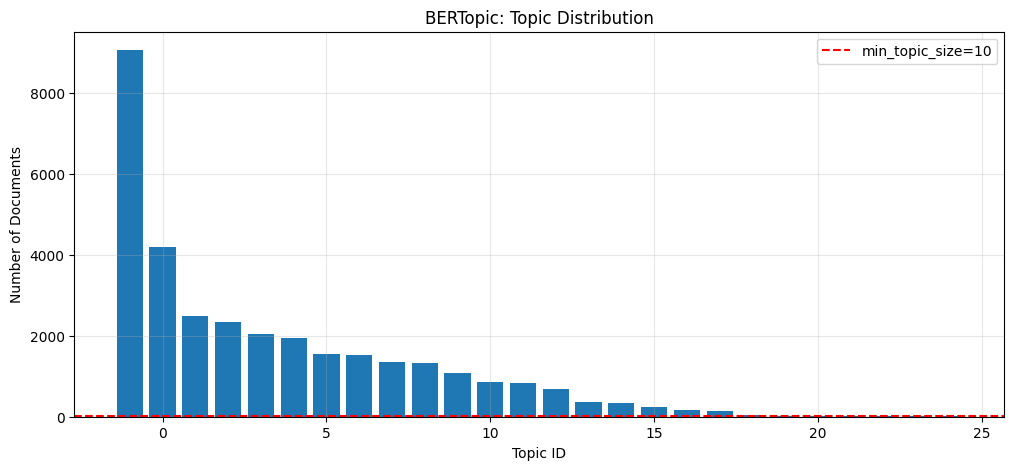


⚠️  Outlier rate: 27.73%


In [11]:
# Cell 6: Inspect topic distribution
import matplotlib.pyplot as plt

unique_topics, topic_counts = np.unique(topics, return_counts=True)

print("=" * 60)
print("TOPIC DISTRIBUTION")
print("=" * 60)

for topic_id, count in zip(unique_topics, topic_counts):
    percentage = count / len(topics) * 100
    if topic_id == -1:
        print(f"Topic {topic_id:3d} (OUTLIERS): {count:5d} docs ({percentage:5.2f}%)")
    else:
        print(f"Topic {topic_id:3d}: {count:5d} docs ({percentage:5.2f}%)")

# Plot distribution
plt.figure(figsize=(12, 5))
plt.bar(unique_topics, topic_counts)
plt.xlabel('Topic ID')
plt.ylabel('Number of Documents')
plt.title('BERTopic: Topic Distribution')
plt.axhline(y=10, color='r', linestyle='--', label='min_topic_size=10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n⚠️  Outlier rate: {sum(1 for t in topics if t == -1) / len(topics) * 100:.2f}%")

In [12]:
# Cell 7: Inspect top topics
print("=" * 60)
print("TOP 5 TOPICS")
print("=" * 60)

topic_info = topic_model.get_topic_info()
print(topic_info.head(6))  # First 5 + outliers

# Show top words for first 5 topics
for topic_id in range(5):
    if topic_id in unique_topics:
        words = topic_model.get_topic(topic_id)[:10]
        print(f"\nTopic {topic_id}:")
        print(f"  {', '.join([word for word, _ in words])}")

TOP 5 TOPICS
   Topic  Count                                    Name  \
0     -1   9056              -1_land_education_bill_use   
1      0   4182     0_education_school_student_students   
2      1   2490                  1_water_energy_gas_oil   
3      2   2341  2_mortgage_consumer_information_agency   
4      3   2037     3_medicare_coverage_insurance_xviii   
5      4   1935           4_tax_credit_internal_revenue   

                                      Representation  \
0  [land, education, bill, use, federal, water, m...   
1  [education, school, student, students, program...   
2  [water, energy, gas, oil, coast_guard, vessel,...   
3  [mortgage, consumer, information, agency, fina...   
4  [medicare, coverage, insurance, xviii, social,...   
5  [tax, credit, internal, revenue, code, income,...   

                                             KeyBERT  \
0  [federal, agencies, congress, agency, grants, ...   
1  [grants, schools, postsecondary, educational, ...   
2  [coast_gu

In [ ]:
topic_words_0 = topic_model.get_topic(0)
len(topic_words_0)

10

In [45]:
topic_words_1 = topic_model.get_topic(1)
len(topic_words_1)

10

In [13]:
# Cell 8: Extract standard outputs
print("=" * 60)
print("EXTRACTING STANDARD OUTPUTS")
print("=" * 60)

# Get topic-word distributions
all_topics = sorted([t for t in unique_topics if t != -1])
num_topics = len(all_topics)

# Build topic-word matrix
topic2word = np.zeros((num_topics, len(vocab)))

for i, topic_id in enumerate(all_topics):
    topic_words = topic_model.get_topic(topic_id)
    for word, score in topic_words:
        if word in vocab_dict:
            word_idx = vocab_dict[word]
            topic2word[i, word_idx] = score

# Normalize to probabilities
topic2word = topic2word / (topic2word.sum(axis=1, keepdims=True) + 1e-10)

print(f"✓ Topic-word matrix: {topic2word.shape}")

# Get document-topic distributions
doc2topic = np.zeros((len(topics), num_topics))

if probs is not None:
    # Use probabilities if available
    for doc_idx, topic_probs in enumerate(probs):
        if topic_probs is not None:
            doc2topic[doc_idx] = topic_probs[:num_topics]
else:
    # Use one-hot encoding based on assigned topic
    for doc_idx, topic_id in enumerate(topics):
        if topic_id >= 0:
            topic_idx = all_topics.index(topic_id)
            doc2topic[doc_idx, topic_idx] = 1.0

print(f"✓ Document-topic matrix: {doc2topic.shape}")

# Calculate topic-doc distribution
topic_sum = doc2topic.sum(axis=0, keepdims=True)
topic2doc = doc2topic / (topic_sum + 1e-10)
topic2doc = topic2doc.T

print(f"✓ Topic-document matrix: {topic2doc.shape}")

EXTRACTING STANDARD OUTPUTS
✓ Topic-word matrix: (25, 15000)
✓ Document-topic matrix: (32661, 25)
✓ Topic-document matrix: (25, 32661)


In [ ]:
# Cell 9: Save outputs
output_dir = 'output/topic_models'
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, f'bertopic_bill_{num_topics}.json')

with open(save_path, 'w') as fp:
    json.dump({
        'topic2word_dist': topic2word.tolist(),
        'doc2topic_dist': doc2topic.tolist(),
        'topic2doc_dist': topic2doc.tolist(),
        'vocab': vocab
    }, fp)

print(f"\n✅ Model outputs saved to: {save_path}")
print(f"\nSaved fields:")
print(f"  - topic2word_dist: ({num_topics}, 15000)")
print(f"  - doc2topic_dist: (32661, {num_topics})")
print(f"  - topic2doc_dist: ({num_topics}, 32661)")
print(f"  - vocab: 15000 words")

# Also save the BERTopic model itself
model_path = os.path.join(output_dir, f'bertopic_bill_{num_topics}.pkl')
topic_model.save(model_path)
print(f"\n✅ BERTopic model saved to: {model_path}")

In [13]:
#let's read the output of the bertopic model
output_path = "/Users/viktor/Desktop/TopicModel/PMLR/output/topic_models/bertopic_wikitext_10.json"
with open(output_path, 'r') as f:
    bertopic_output = json.load(f)

#print the keys of the output
bertopic_output.keys()  # dict_keys(['topic2word_dist', 'doc2topic

dict_keys(['topic2word_dist', 'doc2topic_dist', 'doc2topic_probs', 'topic2doc_dist', 'vocab'])

In [15]:
#print the size of the output, after transforming lists to numpy arrays
topic2word_dist = np.array(bertopic_output['topic2word_dist'])
doc2topic_dist = np.array(bertopic_output['doc2topic_dist'])
topic2doc_dist = np.array(bertopic_output['topic2doc_dist'])

print(f"topic2word_dist shape: {topic2word_dist.shape}")  # (10, vocab_size)
print(f"doc2topic_dist shape: {doc2topic_dist.shape}")      # (num_docs, 10)
print(f"topic2doc_dist shape: {topic2doc_dist.shape}")      # (10, num_docs)

topic2word_dist shape: (10, 15000)
doc2topic_dist shape: (14290, 10)
topic2doc_dist shape: (10, 14290)


In [20]:
doc2topic_probs.sum(axis=1).sum()

3623.0

In [17]:
doc2topic_probs = np.array(bertopic_output['doc2topic_dist'])
doc2topic_probs.shape

(14290, 10)

In [22]:
# read the output of the ctm to see the shape and the sum of the probs gives 1 or not .
ctm_output_10 = "/Users/viktor/Desktop/TopicModel/PMLR/output/topic_models/ctm_wikitext_10.json"
with open(ctm_output_10, 'r') as f:
    ctm_output = json.load(f)

#print the keys of the output
ctm_output.keys()  # dict_keys(['topic2word_dist', 'doc2topic_dist', 'topic2doc_dist'])
topic2word_dist_ctm = np.array(ctm_output['topic2word_dist'])
doc2topic_dist_ctm = np.array(ctm_output['doc2topic_dist'])
topic2doc_dist_ctm = np.array(ctm_output['topic2doc_dist'])

print(f"topic2word_dist_ctm shape: {topic2word_dist_ctm.shape}")  # (10, vocab_size)
print(f"doc2topic_dist_ctm shape: {doc2topic_dist_ctm.shape}")      # (num_docs, 10)
print(f"topic2doc_dist_ctm shape: {topic2doc_dist_ctm.shape}")      # (10, num_docs)

topic2word_dist_ctm shape: (10, 15000)
doc2topic_dist_ctm shape: (14290, 10)
topic2doc_dist_ctm shape: (10, 14290)


In [ ]:
#print whether the sum gives 1 as they should 
doc2topic_dist_ctm.sum(axis=1)

14289.999990014127

In [ ]:
topic2word_dist_ctm.sum(axis=1)

(10,)